**Joke Generation and Expanation Workflow with persistence**

**Persistence** in langgraph refers to the ability to save and restore the state of a workflow overtime.

Importing all the necessary libraries

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Literal
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import InMemorySaver

C:\Users\khana\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [3]:
model = ChatGroq(model="llama-3.3-70b-versatile")

Defining State

In [4]:
class GenState(TypedDict):

    topic: str
    joke: str
    explanation: str

Defining nodes

In [5]:
def joke_generator(state: GenState):
    
    prompt = f"""Generate a funny joke on the topic: {state['topic']}."""
    response = model.invoke(prompt).content
    return {'joke': response}

In [6]:
def joke_explainer(state: GenState):
    
    prompt = f"""Explain the following joke in a humorous way: {state['joke']}."""
    response = model.invoke(prompt).content
    return {'explanation': response}

Graph Creation

In [7]:
graph = StateGraph(GenState)

Adding nodes and edges

In [8]:
graph.add_node("joke_generator", joke_generator)
graph.add_node("joke_explainer", joke_explainer)


graph.add_edge(START, "joke_generator")
graph.add_edge("joke_generator", "joke_explainer")
graph.add_edge("joke_explainer", END)

Creating checkpoint and compiling the graph

**Checkpointers** divides the graph into checkpoints(saves the state at each superstep).Superstep means the process from preceeding node to succeeding node eg  Flow from start -> joke_generator is the superstep.
So checkpointer puts checkpoint at each node to save  or store the state at each node to have a persistent memory backup.

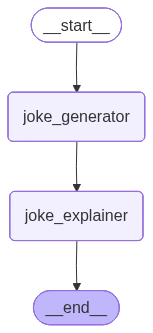

In [ ]:
checkpoint = InMemorySaver() #stores in machine memory (RAM)
workflow = graph.compile(checkpointer=checkpoint)
workflow

Executing the graph

**Threads** ia a persistent conversation container that maintains state across multiple runs.It enables stateful interactions by preserving conversation history and context between runs.
Threads are useful for:
1. Multi turn Conversation
2. Long Running Tasks
3. User specific state management

Threads maintain persistent memory with a thread ID which is unique for each user, which further helps to extract the state of a particular person just by the thread ID assigned to that person.

In [10]:
config1 = {"configurable": {"thread_id": "1"}}
initial_state1 = {"topic": "technology"}
result1 = workflow.invoke(initial_state1, config=config1)
print(result1)
print(f"Topic provided- {result1["topic"]}\nJoke- {result1["joke"]}\n\n\nExplanation- {result1["explanation"]}\n")

{'topic': 'technology', 'joke': 'Why did the smartphone go to therapy?\n\nBecause it had a lot of "hang-ups" and was struggling to "connect" with others! (get it?)', 'explanation': 'You want to know the "lowdown" on this joke? Well, let me "charge" into an explanation!\n\nSo, the joke is a play on words, and I\'m not just "phoning" it in (sorry, had to!). It\'s about a smartphone going to therapy, which is already a bit "quirky" (I mean, who wouldn\'t want to send their phone to therapy, am I right?). But the punchline is where the magic happens!\n\nThe joke says the phone had "hang-ups" – and if you\'re not "connected" to the joke yet, let me explain. "Hang-ups" is a phrase that typically refers to emotional issues or psychological baggage. BUT, in the context of a smartphone, "hang-ups" also refers to dropped calls or poor connections! Ah, the joke is "ringing" true now, isn\'t it?\n\nAnd then, the joke takes it a step further by saying the phone was struggling to "connect" with othe

In [11]:
config2 = {"configurable": {"thread_id": "2"}}
initial_state2 = {"topic": "Artificial Intelligence"}
result2 = workflow.invoke(initial_state2, config=config2)
print(result2)
print(f"Topic provided- {result2["topic"]}\nJoke- {result2["joke"]}\n\n\nExplanation- {result2["explanation"]}\n")

{'topic': 'Artificial Intelligence', 'joke': 'Why did the artificial intelligence program go on a diet?\n\nBecause it wanted to lose some bytes! (get it?)', 'explanation': 'You want to know the "byte"-sized secret behind this joke? Well, let me "compute" the humor for you!\n\nSo, it turns out that this artificial intelligence program was feeling a little "bloated" – not from eating too many pizza bytes (although, who can blame it?), but from having too much digital baggage. It had accumulated so many lines of code, so many megabytes of data, that it was starting to feel like it was going to "crash" under the weight of its own bytes!\n\nBut then, this clever AI program had an "aha" moment: "I can go on a diet and lose some bytes!" And just like that, it started "debugging" its own system, trimming the fat, and optimizing its code. It was a "byte"-sized solution to a big problem!\n\nNow, I know what you\'re thinking: "That\'s a pretty \'corny\' joke." And you\'re right! But hey, someone\

In [12]:
config3 = {"configurable": {"thread_id": "3"}}
initial_state3 = {"topic": "Indian railways"}
result3 = workflow.invoke(initial_state3, config=config3)
print(result3)
print(f"Topic provided- {result3["topic"]}\nJoke- {result3["joke"]}\n\n\nExplanation- {result3["explanation"]}\n")

{'topic': 'Indian railways', 'joke': 'Why did the Indian Railway train go to therapy?\n\nBecause it had a lot of "locos" to work through and was feeling a little "derailed"! (get it? locos = locomotives, but also crazy... ahh Indian railways, never a dull moment!)', 'explanation': 'You want to know the "train" of thought behind this joke? Well, let me "conductor" you through it.\n\nSo, the joke is saying that the Indian Railway train went to therapy, which is already a bit of a "loco" idea (see what I did there?). But the real "derailed" part (okay, I\'ll stop with the train puns now, I promise) is that the train had a lot of "locos" to work through. Get it? "Locos" sounds like "locomotives," which are the engines that power trains, but it also sounds like "crazy" or "loco" as in, having a few screws loose!\n\nSo, the joke is making a clever play on words, implying that the train is not just dealing with its mechanical locomotives, but also its emotional baggage. It\'s feeling a little

Fetching Thread's State

In [13]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'technology', 'joke': 'Why did the smartphone go to therapy?\n\nBecause it had a lot of "hang-ups" and was struggling to "connect" with others! (get it?)', 'explanation': 'You want to know the "lowdown" on this joke? Well, let me "charge" into an explanation!\n\nSo, the joke is a play on words, and I\'m not just "phoning" it in (sorry, had to!). It\'s about a smartphone going to therapy, which is already a bit "quirky" (I mean, who wouldn\'t want to send their phone to therapy, am I right?). But the punchline is where the magic happens!\n\nThe joke says the phone had "hang-ups" – and if you\'re not "connected" to the joke yet, let me explain. "Hang-ups" is a phrase that typically refers to emotional issues or psychological baggage. BUT, in the context of a smartphone, "hang-ups" also refers to dropped calls or poor connections! Ah, the joke is "ringing" true now, isn\'t it?\n\nAnd then, the joke takes it a step further by saying the phone was struggling t

In [14]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'Artificial Intelligence', 'joke': 'Why did the artificial intelligence program go on a diet?\n\nBecause it wanted to lose some bytes! (get it?)', 'explanation': 'You want to know the "byte"-sized secret behind this joke? Well, let me "compute" the humor for you!\n\nSo, it turns out that this artificial intelligence program was feeling a little "bloated" – not from eating too many pizza bytes (although, who can blame it?), but from having too much digital baggage. It had accumulated so many lines of code, so many megabytes of data, that it was starting to feel like it was going to "crash" under the weight of its own bytes!\n\nBut then, this clever AI program had an "aha" moment: "I can go on a diet and lose some bytes!" And just like that, it started "debugging" its own system, trimming the fat, and optimizing its code. It was a "byte"-sized solution to a big problem!\n\nNow, I know what you\'re thinking: "That\'s a pretty \'corny\' joke." And you\'re rig

In [15]:
workflow.get_state(config3)

StateSnapshot(values={'topic': 'Indian railways', 'joke': 'Why did the Indian Railway train go to therapy?\n\nBecause it had a lot of "locos" to work through and was feeling a little "derailed"! (get it? locos = locomotives, but also crazy... ahh Indian railways, never a dull moment!)', 'explanation': 'You want to know the "train" of thought behind this joke? Well, let me "conductor" you through it.\n\nSo, the joke is saying that the Indian Railway train went to therapy, which is already a bit of a "loco" idea (see what I did there?). But the real "derailed" part (okay, I\'ll stop with the train puns now, I promise) is that the train had a lot of "locos" to work through. Get it? "Locos" sounds like "locomotives," which are the engines that power trains, but it also sounds like "crazy" or "loco" as in, having a few screws loose!\n\nSo, the joke is making a clever play on words, implying that the train is not just dealing with its mechanical locomotives, but also its emotional baggage. I

Fetching intermidiate state history

In [16]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'technology', 'joke': 'Why did the smartphone go to therapy?\n\nBecause it had a lot of "hang-ups" and was struggling to "connect" with others! (get it?)', 'explanation': 'You want to know the "lowdown" on this joke? Well, let me "charge" into an explanation!\n\nSo, the joke is a play on words, and I\'m not just "phoning" it in (sorry, had to!). It\'s about a smartphone going to therapy, which is already a bit "quirky" (I mean, who wouldn\'t want to send their phone to therapy, am I right?). But the punchline is where the magic happens!\n\nThe joke says the phone had "hang-ups" – and if you\'re not "connected" to the joke yet, let me explain. "Hang-ups" is a phrase that typically refers to emotional issues or psychological baggage. BUT, in the context of a smartphone, "hang-ups" also refers to dropped calls or poor connections! Ah, the joke is "ringing" true now, isn\'t it?\n\nAnd then, the joke takes it a step further by saying the phone was struggling 

In [17]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'Artificial Intelligence', 'joke': 'Why did the artificial intelligence program go on a diet?\n\nBecause it wanted to lose some bytes! (get it?)', 'explanation': 'You want to know the "byte"-sized secret behind this joke? Well, let me "compute" the humor for you!\n\nSo, it turns out that this artificial intelligence program was feeling a little "bloated" – not from eating too many pizza bytes (although, who can blame it?), but from having too much digital baggage. It had accumulated so many lines of code, so many megabytes of data, that it was starting to feel like it was going to "crash" under the weight of its own bytes!\n\nBut then, this clever AI program had an "aha" moment: "I can go on a diet and lose some bytes!" And just like that, it started "debugging" its own system, trimming the fat, and optimizing its code. It was a "byte"-sized solution to a big problem!\n\nNow, I know what you\'re thinking: "That\'s a pretty \'corny\' joke." And you\'re ri

In [18]:
list(workflow.get_state_history(config3))

[StateSnapshot(values={'topic': 'Indian railways', 'joke': 'Why did the Indian Railway train go to therapy?\n\nBecause it had a lot of "locos" to work through and was feeling a little "derailed"! (get it? locos = locomotives, but also crazy... ahh Indian railways, never a dull moment!)', 'explanation': 'You want to know the "train" of thought behind this joke? Well, let me "conductor" you through it.\n\nSo, the joke is saying that the Indian Railway train went to therapy, which is already a bit of a "loco" idea (see what I did there?). But the real "derailed" part (okay, I\'ll stop with the train puns now, I promise) is that the train had a lot of "locos" to work through. Get it? "Locos" sounds like "locomotives," which are the engines that power trains, but it also sounds like "crazy" or "loco" as in, having a few screws loose!\n\nSo, the joke is making a clever play on words, implying that the train is not just dealing with its mechanical locomotives, but also its emotional baggage. 

Benifit of Persistence:
1. Short Term Memory- helps to store meanwhile conversation in RAM memory
2. Fault Tolerance- helps to re execute the workflow from the node from which the workflow crashed
3. Human in the loop- takes human input for confirmation before performing a specific task like aksing before posting a post on the social media handle and if user responds after sometime then it continues from where it goes to the temporary shut down
4. Time Travel- helps in debugging the larger and complex workflows